In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats
import cartopy.mpl.ticker as cticker
from scipy.ndimage import gaussian_filter
# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')

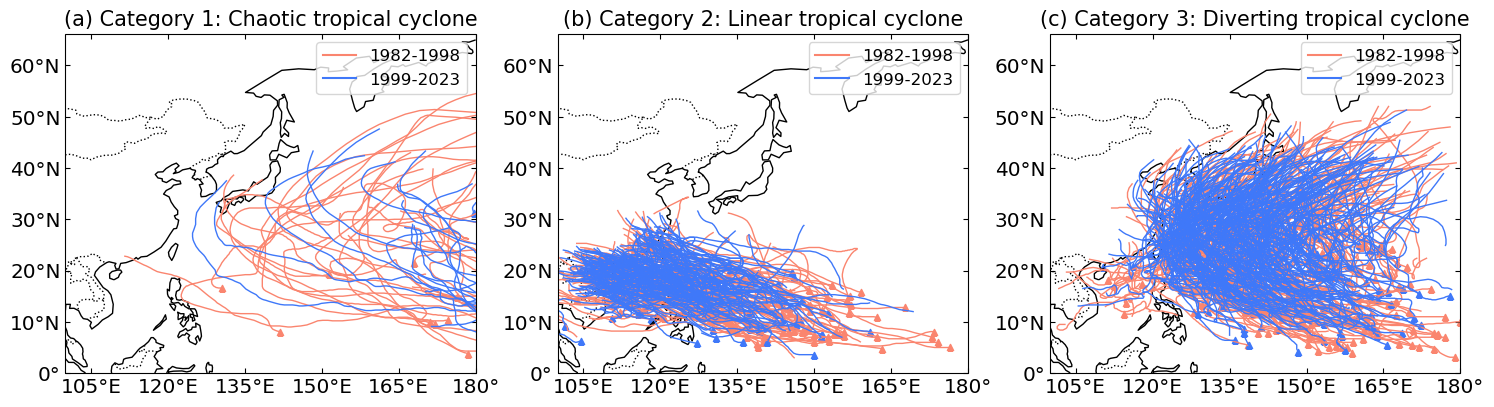

In [3]:
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmaps
label_1 = '1982-1998'  # 蓝色
label_2 = '1999-2023'  # 红色

fig=plt.figure(figsize=(18,6))
ax1=plt.subplot(1,3,1,projection=ccrs.PlateCarree())
ax=ax1
df = pd.read_excel(f'Typhoon_Cluster_1.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 60])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize='x-large')
ax.set_yticklabels(np.arange(0, 61, 10), fontsize='x-large')
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall]  
    if year < 1999:
        color = '#fa856f'
    else:
        color = '#3f78f9'
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1)
    ax.scatter(arrlon[0], arrlat[0], color=color, s=20,marker='^')
legend_lines = [
    mlines.Line2D([], [], color='#fa856f', linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color='#3f78f9', linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper right', fontsize='large')
ax.set_title('(a) Category 1: Chaotic tropical cyclone', fontsize=15,loc='center')

ax2=plt.subplot(1,3,2,projection=ccrs.PlateCarree())
ax=ax2
df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 60])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize='x-large')
ax.set_yticklabels(np.arange(0, 61, 10), fontsize='x-large')
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = '#fa856f'
    else:
        color = '#3f78f9'
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1)
    ax.scatter(arrlon[0], arrlat[0], color=color, s=20,marker='^')
legend_lines = [
    mlines.Line2D([], [], color='#fa856f', linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color='#3f78f9', linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper right', fontsize='large')
ax.set_title('(b) Category 2: Linear tropical cyclone', fontsize=15,loc='center')

ax3=plt.subplot(1,3,3,projection=ccrs.PlateCarree())
ax=ax3
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 60])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize='x-large')
ax.set_yticklabels(np.arange(0, 61, 10), fontsize='x-large')
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = '#fa856f'
    else:
        color = '#3f78f9'
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1)
    ax.scatter(arrlon[0], arrlat[0], color=color,s=20,marker='^')
legend_lines = [
    mlines.Line2D([], [], color='#fa856f', linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color='#3f78f9', linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper right', fontsize='large')
ax.set_title('(c) Category 3: Diverting tropical cyclone', fontsize=15,loc='center')
plt.show()

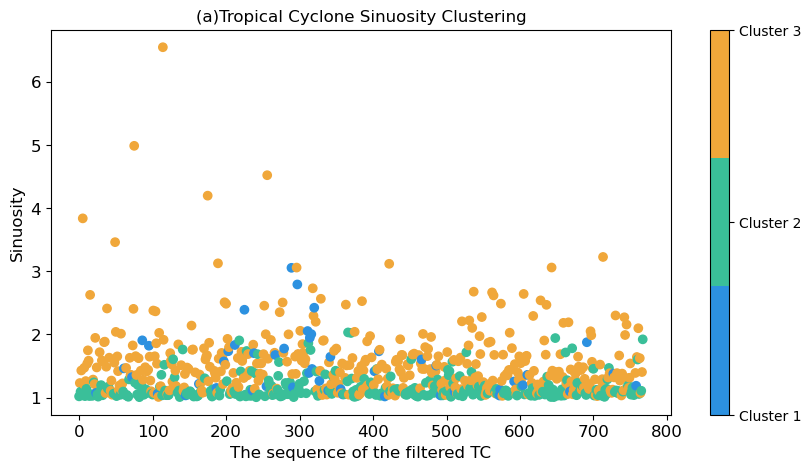

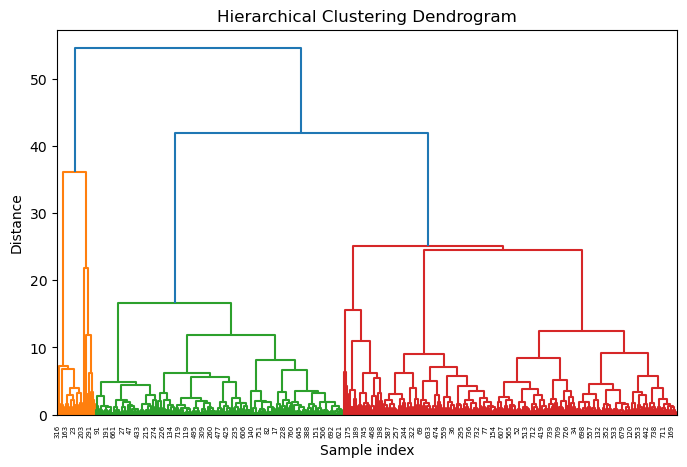

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmaps
from scipy.cluster.hierarchy import dendrogram
# 加载数据
df = pd.read_excel('Typhoon_Curvature_Data.xlsx')

# 提取聚类使用的特征
features = df[[ 'toorilon','toorilat','toendlat', 'toendlon','Curvature','maarrlon','miarrlon']].values

# 数据标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 使用层次聚类
Z = linkage(features_scaled, method='ward')
clusters = fcluster(Z, t=3, criterion='maxclust')

# 将聚类结果添加到 DataFrame
df['Cluster'] = clusters

# 定义离散颜色映射
cmap = ListedColormap(['#2c91e0', '#3abf99', '#f0a73a'])  # 每个聚类分配不同颜色

# 可视化聚类结果
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df.index, df['Curvature'], c=df['Cluster'], cmap=cmap)

# 手动设置 colorbar 标签
cbar = plt.colorbar(scatter, ticks=[1, 2, 3])
# cbar.set_label('Cluster')
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])

plt.xlabel('The sequence of the filtered TC', fontsize=12)
plt.ylabel('Sinuosity', fontsize=12)
plt.title('(a)Tropical Cyclone Sinuosity Clustering', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


plt.figure(figsize=(8, 5))  # 调整图像大小
dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')

# 旋转标签，并减少标签的密集度
plt.xticks(rotation=90)  # 旋转标签
plt.gca().set_xticks(plt.gca().get_xticks()[::10])  # 每隔10个显示一个标签

plt.show()


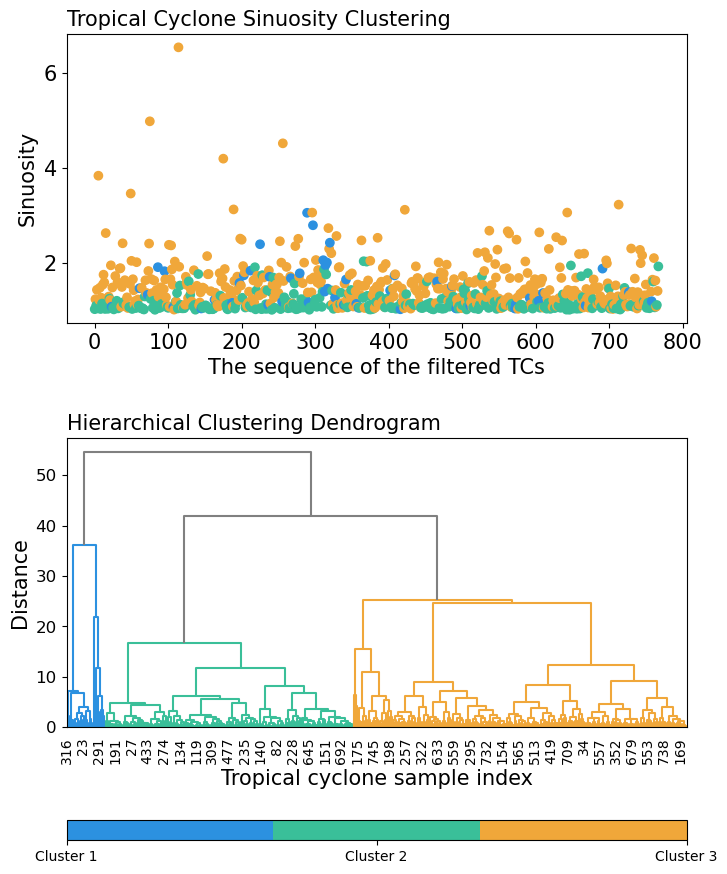

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.cluster import hierarchy

# 加载数据
df = pd.read_excel('Typhoon_Curvature_Data.xlsx')

# 提取聚类使用的特征
features = df[['toorilon', 'toorilat', 'toendlat', 'toendlon', 'Curvature', 'maarrlon', 'miarrlon']].values

# 数据标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 使用层次聚类
Z = linkage(features_scaled, method='ward')
clusters = fcluster(Z, t=3, criterion='maxclust')

# 将聚类结果添加到 DataFrame
df['Cluster'] = clusters

# 定义离散颜色映射
cmap = ListedColormap(['#2c91e0', '#3abf99', '#f0a73a'])  # 每个聚类分配不同颜色

# 创建一个颜色映射字典
cluster_colors = {1: '#2c91e0', 2: '#3abf99', 3: '#f0a73a'}

# 设置 dendrogram 使用的颜色
hierarchy.set_link_color_palette(['#2c91e0', '#3abf99', '#f0a73a'])  # 设置成聚类结果对应的颜色

# 创建2x1的子图布局
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.4)  # 两行子图

# 第一个子图：聚类结果
ax1 = fig.add_subplot(gs[0])
scatter = ax1.scatter(df.index, df['Curvature'], c=df['Cluster'], cmap=cmap)
ax1.set_xlabel('The sequence of the filtered TCs', fontsize=15)
ax1.set_ylabel('Sinuosity', fontsize=15)
ax1.set_title('Tropical Cyclone Sinuosity Clustering',loc='left',fontsize=15)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)

# 第二个子图：树状图，设置颜色
ax2 = fig.add_subplot(gs[1])
hierarchy.dendrogram(Z, ax=ax2, above_threshold_color='gray')  # 使用自定义颜色
ax2.set_xlabel('Tropical cyclone sample index', fontsize=15)
ax2.set_ylabel('Distance', fontsize=15)
ax2.tick_params(axis='x', labelsize=10, rotation=90)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_xticks(ax2.get_xticks()[::20])  # 每隔10个显示一个标签
ax2.set_title('Hierarchical Clustering Dendrogram', fontsize=15,loc='left')

# 在底部创建一个共用的 colorbar，调整位置
cbar = fig.colorbar(scatter, ax=[ax1, ax2], orientation='horizontal', pad=0.1, aspect=30)  # pad增加了 colorbar 的间距
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])

# 重置颜色调色板
hierarchy.set_link_color_palette(None)
plt.savefig("Figure S2.pdf",transparent = True)
plt.show()
